# 6. Learning from Imbalanced Data

Since chapter 1 we have been noting that 65% of these patients tested negative, and that this makes accuracy a poor summary. This chapter does something about it.

Imbalance is the normal case, not an edge case. Fraud, disease, equipment failure, churn — in every one of them the interesting class is the rare one, and in every one of them a model that ignores its input scores well.

**You will learn:**

- what imbalance does to a classifier, and why accuracy conceals it
- how oversampling, undersampling and SMOTE differ
- that every one of them makes accuracy *worse* — and why that is the point
- why a sampler outside the fold inflates your score by six points
- the two alternatives to resampling that cost nothing

**Prerequisites:** chapters 2 and 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tuiml.datasets import load_diabetes
from tuiml.workflow import Workflow
from tuiml.preprocessing import SimpleImputer
from tuiml.algorithms.trees import RandomForestClassifier
from tuiml.evaluation import (
    StratifiedKFold, accuracy_score, precision_score, recall_score, f1_score,
)

data = load_diabetes()
y = data.y

X = data.X.copy()
for name in ["plas", "pres", "skin", "insu", "mass"]:
    col = data.feature_names.index(name)
    X[X[:, col] == 0, col] = np.nan
X = SimpleImputer(strategy="median").fit_transform(X)

counts = np.bincount(y)
print(f"negative: {counts[0]:3d}  ({counts[0] / len(y):.1%})")
print(f"positive: {counts[1]:3d}  ({counts[1] / len(y):.1%})")
print(f"ratio   : {counts[0] / counts[1]:.2f} : 1")

negative: 500  (65.1%)
positive: 268  (34.9%)
ratio   : 1.87 : 1


## 6.1 What imbalance does

A classifier minimising overall error has a cheap strategy available: predict the majority class more often. Every time it does, it is right 65% of the time for free, and the gradient pushing it toward correctly identifying the minority is proportionally weaker.

The result is a model that is accurate and useless — good at the class you did not care about.

Here is the effect on our forest, per class:

In [2]:
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


def evaluate(make_model):
    """Cross-validate and return accuracy, precision, recall and F1 for the positive class."""
    acc, prec, rec, f1 = [], [], [], []
    for train_idx, test_idx in splitter.split(X, y):
        model = make_model().fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        acc.append(accuracy_score(y[test_idx], pred))
        prec.append(precision_score(y[test_idx], pred))
        rec.append(recall_score(y[test_idx], pred))
        f1.append(f1_score(y[test_idx], pred))
    return np.mean(acc), np.mean(prec), np.mean(rec), np.mean(f1)


forest = lambda: RandomForestClassifier(n_estimators=200, random_state=42)
base_acc, base_prec, base_rec, base_f1 = evaluate(forest)

print(f"accuracy : {base_acc:.4f}   <- looks fine")
print(f"recall   : {base_rec:.4f}   <- we miss ~38% of diabetic patients")
print(f"precision: {base_prec:.4f}")
print(f"F1       : {base_f1:.4f}")

accuracy : 0.7669   <- looks fine
recall   : 0.6155   <- we miss ~38% of diabetic patients
precision: 0.6844
F1       : 0.6446


Chapter 2 established that the do-nothing baseline scores 0.65. Our model is at 0.77 — a real improvement — while missing nearly four in ten of the people it exists to find. Accuracy simply does not surface that.

## 6.2 Resampling

The most direct response is to change the training data so the classes are balanced.

**Random oversampling** duplicates minority rows until the classes match. Simple, and it risks the model memorising the duplicated points.

**Random undersampling** discards majority rows instead. It throws away real data, which is painful on a small dataset, but it never invents anything.

**SMOTE** (Synthetic Minority Over-sampling Technique) interpolates: it picks a minority point, picks one of its *k* nearest minority neighbours, and creates a new point somewhere on the line between them. You get new rows that are plausible without being copies.

**ADASYN** is SMOTE weighted toward the minority points that are hardest to classify — the ones near the boundary — on the theory that those are where extra examples help most.

In [3]:
from tuiml.preprocessing import SMOTESampler

sampler = SMOTESampler(random_state=42)
X_resampled, y_resampled = sampler.fit_resample(X, y)

print(f"before: {X.shape[0]} rows, classes {np.bincount(y)}")
print(f"after : {X_resampled.shape[0]} rows, classes {np.bincount(y_resampled)}")

before: 768 rows, classes [500 268]
after : 1000 rows, classes [500 500]


It is worth seeing what synthesis actually produces. Here are two features, with the original minority points and the ones SMOTE invented:

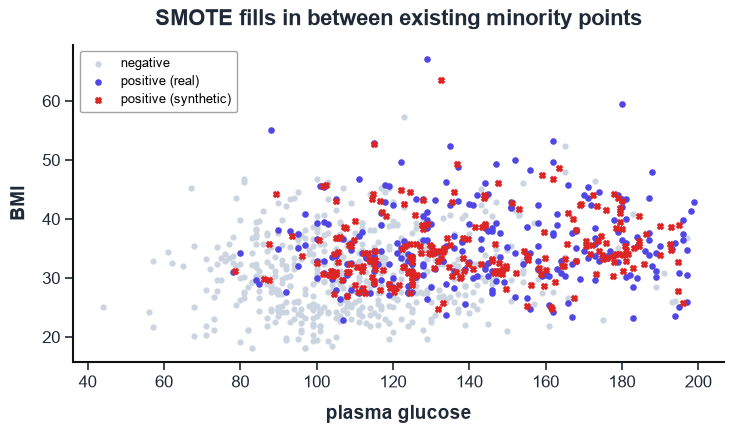

In [4]:
glucose = data.feature_names.index("plas")
bmi = data.feature_names.index("mass")

n_original = len(X)
synthetic = X_resampled[n_original:]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(X[y == 0, glucose], X[y == 0, bmi], s=12, c="#cbd5e1", label="negative")
ax.scatter(X[y == 1, glucose], X[y == 1, bmi], s=14, c="#4f46e5", label="positive (real)")
ax.scatter(synthetic[:, glucose], synthetic[:, bmi], s=14, c="#dc2626",
           marker="x", label="positive (synthetic)")
ax.set_xlabel("plasma glucose")
ax.set_ylabel("BMI")
ax.set_title("SMOTE fills in between existing minority points")
ax.legend(loc="upper left", fontsize=9)
plt.show()

The synthetic points sit inside the convex hull of the real ones — SMOTE interpolates, it never extrapolates. That is its safety property and also its limitation: it cannot tell you about a region of the space where you have no positive examples at all.

## 6.3 Measuring what resampling buys

Samplers are `Workflow` steps, so they are fitted inside the fold like everything else. Compare them all:

In [5]:
from tuiml.preprocessing import RandomOverSampler, RandomUnderSampler, ADASYNSampler

strategies = {
    "none": lambda: forest(),
    "SMOTE": lambda: Workflow([SMOTESampler(random_state=42), forest()]),
    "ADASYN": lambda: Workflow([ADASYNSampler(random_state=42), forest()]),
    "random oversample": lambda: Workflow([RandomOverSampler(random_state=42), forest()]),
    "random undersample": lambda: Workflow([RandomUnderSampler(random_state=42), forest()]),
}

print(f"{'strategy':20s} {'accuracy':>9s} {'precision':>10s} {'recall':>8s} {'F1':>8s}")
print("-" * 58)
for label, make in strategies.items():
    acc, prec, rec, f1 = evaluate(make)
    print(f"{label:20s} {acc:9.4f} {prec:10.4f} {rec:8.4f} {f1:8.4f}")

strategy              accuracy  precision   recall       F1
----------------------------------------------------------


none                    0.7669     0.6844   0.6155   0.6446


SMOTE                   0.7604     0.6494   0.6976   0.6689


ADASYN                  0.7604     0.6431   0.7164   0.6757


random oversample       0.7682     0.6684   0.6752   0.6682


random undersample      0.7512     0.6193   0.7835   0.6863


Read the accuracy column first: no sampler improved it meaningfully, and three of the four made it worse — random oversampling comes out a thousandth ahead, which is comfortably inside the fold-to-fold noise from chapter 2.

Now read the recall column: **every sampler made it better**, and undersampling improved it by nearly seventeen points.

That is not a paradox, it is the trade being made explicit. Resampling moves the model's decision boundary toward the minority class. It catches more positives and raises more false alarms; accuracy, which counts both errors equally, goes down. F1 — which is about the minority class — goes up for every strategy.

> **Remark — resampling cannot create information.** It rebalances the *cost* of the two errors, which is a decision about what you want, not a discovery about the data. If you find yourself hoping SMOTE will raise accuracy, you have the wrong mental model: it is closer to moving the threshold in chapter 2 than to learning something new.

Which points at something worth knowing before you reach for a sampler at all.

## 6.4 The two cheaper alternatives

**Move the threshold.** Chapter 2 showed that dropping the cut-off from 0.5 to 0.3 took recall from 0.53 to 0.83 on this data. No resampling, no retraining, one number.

In [6]:
from tuiml.evaluation import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

plain = forest().fit(X_train, y_train)
probabilities = plain.predict_proba(X_test)[:, 1]

smote_model = Workflow([SMOTESampler(random_state=42), forest()]).fit(X_train, y_train)
smote_pred = smote_model.predict(X_test)

threshold_pred = (probabilities >= 0.35).astype(int)

print(f"{'approach':28s} {'recall':>8s} {'precision':>10s}")
print("-" * 48)
print(f"{'plain, threshold 0.5':28s} {recall_score(y_test, plain.predict(X_test)):8.3f} "
      f"{precision_score(y_test, plain.predict(X_test)):10.3f}")
print(f"{'SMOTE, threshold 0.5':28s} {recall_score(y_test, smote_pred):8.3f} "
      f"{precision_score(y_test, smote_pred):10.3f}")
print(f"{'plain, threshold 0.35':28s} {recall_score(y_test, threshold_pred):8.3f} "
      f"{precision_score(y_test, threshold_pred):10.3f}")

approach                       recall  precision
------------------------------------------------
plain, threshold 0.5            0.566      0.732
SMOTE, threshold 0.5            0.623      0.702
plain, threshold 0.35           0.792      0.689


Threshold tuning reaches the same territory without synthesising a single row, and it leaves you with one interpretable dial instead of a modified training set. On many problems this is all you need.

**Class weights.** Many algorithms accept a per-class penalty, telling the loss function that a minority mistake costs more. Where available it is the cleanest option, because it changes the objective rather than the data.

## 6.5 Resampling belongs inside the fold

Chapter 5 showed feature selection leaking thirty points. Resampling is the other big one, and it leaks for a different reason.

In [7]:
from tuiml.evaluation import cross_val_score

# WRONG: resample the whole dataset, then cross-validate on the result.
X_leaked, y_leaked = SMOTESampler(random_state=42).fit_resample(X, y)
leaky = cross_val_score(
    forest(), X_leaked, y_leaked,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
).mean()

honest = cross_val_score(
    Workflow([SMOTESampler(random_state=42), forest()]), X, y, cv=splitter,
).mean()

print(f"SMOTE before splitting (wrong): {leaky:.4f}")
print(f"SMOTE inside the fold  (right): {honest:.4f}")
print(f"inflation                     : {leaky - honest:+.4f}")

SMOTE before splitting (wrong): 0.8230
SMOTE inside the fold  (right): 0.7604
inflation                     : +0.0626


Six points of pure fiction.

The mechanism is specific and worth understanding, because it is not the usual "the transform saw the test statistics". SMOTE builds each synthetic point by interpolating between two real minority points. Resample first, and a synthetic row constructed from patient A can land in the training fold while **patient A herself lands in the test fold**. The model then gets tested on someone it has effectively already seen, in blurred form.

Undersampling before splitting is just as bad in the other direction: rows deleted from the test set make the test set easier.

> **Remark.** This is the third leak in three chapters — imputation (negligible), feature selection (thirty points), resampling (six points). The magnitudes vary enormously and there is no reliable intuition for guessing them in advance. The rule that requires no intuition: **if it learns anything from the data, it goes inside the `Workflow`.**

## 6.6 Choosing

| Situation | Try |
|---|---|
| Mild imbalance (up to ~4:1) | Threshold tuning; often nothing else is needed |
| The model supports class weights | Class weights, before touching the data |
| Moderate imbalance, enough minority rows | SMOTE or ADASYN inside the pipeline |
| Severe imbalance, plenty of majority rows | Undersampling, or a combination |
| Very few minority rows in absolute terms | Get more data; synthesis cannot rescue 12 examples |

And whatever you choose: report precision, recall and F1, never accuracy alone. Every technique in this chapter is designed to make accuracy worse.

## Recap

- Imbalance makes "predict the majority" a cheap winning strategy; the model ends up good at the class you do not care about.
- Our forest scored 0.77 accuracy while missing ~38% of diabetic patients.
- Oversampling duplicates, undersampling discards, **SMOTE interpolates** between minority neighbours, ADASYN focuses on the hard ones.
- **Every sampler raised recall, and none improved accuracy.** That is the trade, and it is the point.
- Resampling rebalances the cost of the two errors. It does not create information — it is closer to moving the threshold than to learning.
- Threshold tuning and class weights get you much of the way for free. Try them first.
- **SMOTE before splitting inflated the score by six points**, because synthetic rows built from a test patient end up in the training fold.
- Report precision, recall and F1. Never accuracy alone on imbalanced data.

**Next:** chapter 7 stops accepting the default algorithm and default hyperparameters, and searches for both.